# Warehouse Outbound Process - Stutter Equivalence Verification

This notebook demonstrates verification of a complex **multi-station warehouse outbound process** modeled in both Event Graph and ACD formalisms.

## Warehouse Process Overview

The warehouse has 6 service stations:
- **S1**: Pick Zone A (4 servers)
- **S2**: Pick Zone B (2 servers)
- **S3**: Label (3 servers)
- **S4**: Scan (1 server)
- **S5**: Pack (3 servers)
- **S6**: Release (2 servers)

Jobs enter through 4 creation streams (2 for Zone A, 2 for Zone B), then flow through Label → Scan → Pack → Release.

## Observation Level W

We verify equivalence using:

**W = { s1_busy_eq_*, s2_busy_eq_*, s3_busy_eq_*, s4_busy_eq_*, s5_busy_eq_*, s6_busy_eq_* }**

This tracks the number of busy servers at each station.

In [1]:
# Install simasm (uncomment in Colab)
# !pip install simasm

import simasm
print(f"SimASM version: {simasm.__version__}")

SimASM version: 0.4.4


## 1. Define Warehouse Event Graph JSON

In [2]:
# Warehouse Event Graph JSON specification
warehouse_eg_json = {
  "model_name": "warehouse_eg",
  "description": "Warehouse Outbound Process using Event Graph formalism (Schruben 1983)",

  "state_variables": {
    "Q1": {"type": "Nat", "initial": 0, "description": "Pick Zone A queue"},
    "Q2": {"type": "Nat", "initial": 0, "description": "Pick Zone B queue"},
    "Q3": {"type": "Nat", "initial": 0, "description": "Labelling queue"},
    "Q4": {"type": "Nat", "initial": 0, "description": "Scanning queue"},
    "Q5": {"type": "Nat", "initial": 0, "description": "Packing queue"},
    "Q6": {"type": "Nat", "initial": 0, "description": "Release queue"},
    "S1": {"type": "Nat", "initial": 4, "description": "Pick Zone A available servers"},
    "S2": {"type": "Nat", "initial": 2, "description": "Pick Zone B available servers"},
    "S3": {"type": "Nat", "initial": 3, "description": "Labelling available servers"},
    "S4": {"type": "Nat", "initial": 1, "description": "Scanning available servers"},
    "S5": {"type": "Nat", "initial": 3, "description": "Packing available servers"},
    "S6": {"type": "Nat", "initial": 2, "description": "Release available servers"},
    "departures": {"type": "Nat", "initial": 0, "description": "Total completed jobs"}
  },

  "parameters": {
    "Q1_max": {"type": "Nat", "value": 30}, "Q2_max": {"type": "Nat", "value": 20},
    "Q3_max": {"type": "Nat", "value": 50}, "Q4_max": {"type": "Nat", "value": 20},
    "Q5_max": {"type": "Nat", "value": 30}, "Q6_max": {"type": "Nat", "value": 20},
    "S1_capacity": {"type": "Nat", "value": 4}, "S2_capacity": {"type": "Nat", "value": 2},
    "S3_capacity": {"type": "Nat", "value": 3}, "S4_capacity": {"type": "Nat", "value": 1},
    "S5_capacity": {"type": "Nat", "value": 3}, "S6_capacity": {"type": "Nat", "value": 2},
    "iat_c1_mean": {"type": "Real", "value": 325.5}, "iat_c2_mean": {"type": "Real", "value": 527.6},
    "iat_c3_mean": {"type": "Real", "value": 226.1}, "iat_c4_mean": {"type": "Real", "value": 985.6},
    "ist_s1_mean": {"type": "Real", "value": 78.4}, "ist_s2_mean": {"type": "Real", "value": 76.2},
    "ist_s3_mean": {"type": "Real", "value": 288.8}, "ist_s4_mean": {"type": "Real", "value": 31.2},
    "ist_s5_mean": {"type": "Real", "value": 66.8}, "ist_s6_mean": {"type": "Real", "value": 1.0},
    "sim_end_time": {"type": "Real", "value": 10000.0}
  },

  "random_streams": {
    "T_c1": {"distribution": "exponential", "params": {"mean": "iat_c1_mean"}, "stream_name": "creation_za1"},
    "T_c2": {"distribution": "exponential", "params": {"mean": "iat_c2_mean"}, "stream_name": "creation_za2"},
    "T_c3": {"distribution": "exponential", "params": {"mean": "iat_c3_mean"}, "stream_name": "creation_zb1"},
    "T_c4": {"distribution": "exponential", "params": {"mean": "iat_c4_mean"}, "stream_name": "creation_zb2"},
    "T_s1": {"distribution": "exponential", "params": {"mean": "ist_s1_mean"}, "stream_name": "service_pick_a"},
    "T_s2": {"distribution": "exponential", "params": {"mean": "ist_s2_mean"}, "stream_name": "service_pick_b"},
    "T_s3": {"distribution": "exponential", "params": {"mean": "ist_s3_mean"}, "stream_name": "service_label"},
    "T_s4": {"distribution": "exponential", "params": {"mean": "ist_s4_mean"}, "stream_name": "service_scan"},
    "T_s5": {"distribution": "exponential", "params": {"mean": "ist_s5_mean"}, "stream_name": "service_pack"},
    "T_s6": {"distribution": "exponential", "params": {"mean": "ist_s6_mean"}, "stream_name": "service_release"}
  },

  "vertices": [
    {"name": "CreateZA1", "state_change": "", "description": "Create Zone A Type 1 job"},
    {"name": "CreateZA2", "state_change": "", "description": "Create Zone A Type 2 job"},
    {"name": "CreateZB1", "state_change": "", "description": "Create Zone B Type 1 job"},
    {"name": "CreateZB2", "state_change": "", "description": "Create Zone B Type 2 job"},
    {"name": "AttemptQueueZAT1", "state_change": "", "description": "Attempt Queue Zone A Type 1"},
    {"name": "AttemptQueueZAT2", "state_change": "", "description": "Attempt Queue Zone A Type 2"},
    {"name": "AttemptQueueZBT1", "state_change": "", "description": "Attempt Queue Zone B Type 1"},
    {"name": "AttemptQueueZBT2", "state_change": "", "description": "Attempt Queue Zone B Type 2"},
    {"name": "QueueQ1", "state_change": "Q1 := Q1 + 1", "description": "Queue in Pick Zone A"},
    {"name": "QueueQ2", "state_change": "Q2 := Q2 + 1", "description": "Queue in Pick Zone B"},
    {"name": "AttemptPickA", "state_change": "", "description": "Attempt Pick Zone A"},
    {"name": "AttemptPickB", "state_change": "", "description": "Attempt Pick Zone B"},
    {"name": "StartPickA", "state_change": "Q1 := Q1 - 1; S1 := S1 - 1", "description": "Start Pick A"},
    {"name": "StartPickB", "state_change": "Q2 := Q2 - 1; S2 := S2 - 1", "description": "Start Pick B"},
    {"name": "FinishPickA", "state_change": "S1 := S1 + 1", "description": "Finish Pick A"},
    {"name": "FinishPickB", "state_change": "S2 := S2 + 1", "description": "Finish Pick B"},
    {"name": "AttemptQueueQ3", "state_change": "", "description": "Attempt Queue after Picking"},
    {"name": "QueueQ3", "state_change": "Q3 := Q3 + 1", "description": "Queue after Picking"},
    {"name": "AttemptLabel", "state_change": "", "description": "Attempt Label"},
    {"name": "StartLabel", "state_change": "Q3 := Q3 - 1; S3 := S3 - 1", "description": "Start Label"},
    {"name": "FinishLabel", "state_change": "S3 := S3 + 1", "description": "Finish Label"},
    {"name": "AttemptQueueQ4", "state_change": "", "description": "Attempt Queue after Labelling"},
    {"name": "QueueQ4", "state_change": "Q4 := Q4 + 1", "description": "Queue after Labelling"},
    {"name": "AttemptScan", "state_change": "", "description": "Attempt Scan"},
    {"name": "StartScan", "state_change": "Q4 := Q4 - 1; S4 := S4 - 1", "description": "Start Scan"},
    {"name": "FinishScan", "state_change": "S4 := S4 + 1", "description": "Finish Scan"},
    {"name": "AttemptQueueQ5", "state_change": "", "description": "Attempt Queue after Scanning"},
    {"name": "QueueQ5", "state_change": "Q5 := Q5 + 1", "description": "Queue after Scanning"},
    {"name": "AttemptPack", "state_change": "", "description": "Attempt Pack"},
    {"name": "StartPack", "state_change": "Q5 := Q5 - 1; S5 := S5 - 1", "description": "Start Pack"},
    {"name": "FinishPack", "state_change": "S5 := S5 + 1", "description": "Finish Pack"},
    {"name": "AttemptQueueQ6", "state_change": "", "description": "Attempt Queue after Packing"},
    {"name": "QueueQ6", "state_change": "Q6 := Q6 + 1", "description": "Queue after Packing"},
    {"name": "AttemptRelease", "state_change": "", "description": "Attempt Release"},
    {"name": "StartRelease", "state_change": "Q6 := Q6 - 1; S6 := S6 - 1", "description": "Start Release"},
    {"name": "FinishRelease", "state_change": "S6 := S6 + 1; departures := departures + 1", "description": "Finish Release"}
  ],

  "scheduling_edges": [
    # Creation streams - reschedule self and attempt to queue
    {"from": "CreateZA1", "to": "CreateZA1", "delay": "T_c1", "condition": "true", "priority": 1},
    {"from": "CreateZA1", "to": "AttemptQueueZAT1", "delay": 0, "condition": "true", "priority": 1},
    {"from": "CreateZA2", "to": "CreateZA2", "delay": "T_c2", "condition": "true", "priority": 2},
    {"from": "CreateZA2", "to": "AttemptQueueZAT2", "delay": 0, "condition": "true", "priority": 2},
    {"from": "CreateZB1", "to": "CreateZB1", "delay": "T_c3", "condition": "true", "priority": 3},
    {"from": "CreateZB1", "to": "AttemptQueueZBT1", "delay": 0, "condition": "true", "priority": 3},
    {"from": "CreateZB2", "to": "CreateZB2", "delay": "T_c4", "condition": "true", "priority": 4},
    {"from": "CreateZB2", "to": "AttemptQueueZBT2", "delay": 0, "condition": "true", "priority": 4},
    # Queue admission control
    {"from": "AttemptQueueZAT1", "to": "QueueQ1", "delay": 0, "condition": "Q1 < Q1_max", "priority": 5},
    {"from": "AttemptQueueZAT2", "to": "QueueQ1", "delay": 0, "condition": "Q1 < Q1_max", "priority": 5},
    {"from": "AttemptQueueZBT1", "to": "QueueQ2", "delay": 0, "condition": "Q2 < Q2_max", "priority": 5},
    {"from": "AttemptQueueZBT2", "to": "QueueQ2", "delay": 0, "condition": "Q2 < Q2_max", "priority": 5},
    # After queueing, attempt to start service
    {"from": "QueueQ1", "to": "AttemptPickA", "delay": 0, "condition": "true", "priority": 6},
    {"from": "QueueQ2", "to": "AttemptPickB", "delay": 0, "condition": "true", "priority": 6},
    # Pick Zone A service
    {"from": "AttemptPickA", "to": "StartPickA", "delay": 0, "condition": "S1 > 0 and Q1 > 0", "priority": 7},
    {"from": "StartPickA", "to": "FinishPickA", "delay": "T_s1", "condition": "true", "priority": 5},
    {"from": "FinishPickA", "to": "AttemptQueueQ3", "delay": 0, "condition": "true", "priority": 7},
    {"from": "FinishPickA", "to": "AttemptPickA", "delay": 0, "condition": "true", "priority": 7},
    # Pick Zone B service
    {"from": "AttemptPickB", "to": "StartPickB", "delay": 0, "condition": "S2 > 0 and Q2 > 0", "priority": 7},
    {"from": "StartPickB", "to": "FinishPickB", "delay": "T_s2", "condition": "true", "priority": 6},
    {"from": "FinishPickB", "to": "AttemptQueueQ3", "delay": 0, "condition": "true", "priority": 6},
    {"from": "FinishPickB", "to": "AttemptPickB", "delay": 0, "condition": "true", "priority": 6},
    # Label queue and service
    {"from": "AttemptQueueQ3", "to": "QueueQ3", "delay": 0, "condition": "Q3 < Q3_max", "priority": 8},
    {"from": "QueueQ3", "to": "AttemptLabel", "delay": 0, "condition": "true", "priority": 9},
    {"from": "AttemptLabel", "to": "StartLabel", "delay": 0, "condition": "S3 > 0 and Q3 > 0", "priority": 7},
    {"from": "StartLabel", "to": "FinishLabel", "delay": "T_s3", "condition": "true", "priority": 7},
    {"from": "FinishLabel", "to": "AttemptQueueQ4", "delay": 0, "condition": "true", "priority": 8},
    {"from": "FinishLabel", "to": "AttemptLabel", "delay": 0, "condition": "true", "priority": 7},
    # Scan queue and service
    {"from": "AttemptQueueQ4", "to": "QueueQ4", "delay": 0, "condition": "Q4 < Q4_max", "priority": 9},
    {"from": "QueueQ4", "to": "AttemptScan", "delay": 0, "condition": "true", "priority": 10},
    {"from": "AttemptScan", "to": "StartScan", "delay": 0, "condition": "S4 > 0 and Q4 > 0", "priority": 8},
    {"from": "StartScan", "to": "FinishScan", "delay": "T_s4", "condition": "true", "priority": 8},
    {"from": "FinishScan", "to": "AttemptQueueQ5", "delay": 0, "condition": "true", "priority": 9},
    {"from": "FinishScan", "to": "AttemptScan", "delay": 0, "condition": "true", "priority": 8},
    # Pack queue and service
    {"from": "AttemptQueueQ5", "to": "QueueQ5", "delay": 0, "condition": "Q5 < Q5_max", "priority": 10},
    {"from": "QueueQ5", "to": "AttemptPack", "delay": 0, "condition": "true", "priority": 9},
    {"from": "AttemptPack", "to": "StartPack", "delay": 0, "condition": "S5 > 0 and Q5 > 0", "priority": 9},
    {"from": "StartPack", "to": "FinishPack", "delay": "T_s5", "condition": "true", "priority": 9},
    {"from": "FinishPack", "to": "AttemptQueueQ6", "delay": 0, "condition": "true", "priority": 10},
    {"from": "FinishPack", "to": "AttemptPack", "delay": 0, "condition": "true", "priority": 9},
    # Release queue and service
    {"from": "AttemptQueueQ6", "to": "QueueQ6", "delay": 0, "condition": "Q6 < Q6_max", "priority": 10},
    {"from": "QueueQ6", "to": "AttemptRelease", "delay": 0, "condition": "true", "priority": 10},
    {"from": "AttemptRelease", "to": "StartRelease", "delay": 0, "condition": "S6 > 0 and Q6 > 0", "priority": 10},
    {"from": "StartRelease", "to": "FinishRelease", "delay": "T_s6", "condition": "true", "priority": 10},
    {"from": "FinishRelease", "to": "AttemptRelease", "delay": 0, "condition": "true", "priority": 10}
  ],

  "cancelling_edges": [],

  "initial_events": [
    {"event": "CreateZA1", "time": "T_c1"},
    {"event": "CreateZA2", "time": "T_c2"},
    {"event": "CreateZB1", "time": "T_c3"},
    {"event": "CreateZB2", "time": "T_c4"}
  ],

  "stopping_condition": "sim_clocktime >= sim_end_time",

  "observables": {
    "get_S1_busy": {"expression": "S1_capacity - S1", "return_type": "Nat"},
    "get_S2_busy": {"expression": "S2_capacity - S2", "return_type": "Nat"},
    "get_S3_busy": {"expression": "S3_capacity - S3", "return_type": "Nat"},
    "get_S4_busy": {"expression": "S4_capacity - S4", "return_type": "Nat"},
    "get_S5_busy": {"expression": "S5_capacity - S5", "return_type": "Nat"},
    "get_S6_busy": {"expression": "S6_capacity - S6", "return_type": "Nat"}
  }
}

print(f"Warehouse EG JSON defined with {len(warehouse_eg_json['vertices'])} vertices")

# Save JSON to file for the converter
import json
with open("warehouse_eg.json", "w") as f:
    json.dump(warehouse_eg_json, f, indent=2)
print("Saved warehouse_eg.json")

Warehouse EG JSON defined with 36 vertices
Saved warehouse_eg.json


## 2. Define Warehouse ACD JSON

In [3]:
# Warehouse ACD JSON specification
warehouse_acd_json = {
  "model_name": "warehouse_acd",
  "description": "Warehouse Outbound Process using Activity Cycle Diagram formalism",

  "parameters": {
    "Q1_max": {"type": "Nat", "value": 30}, "Q2_max": {"type": "Nat", "value": 20},
    "Q3_max": {"type": "Nat", "value": 50}, "Q4_max": {"type": "Nat", "value": 20},
    "Q5_max": {"type": "Nat", "value": 30}, "Q6_max": {"type": "Nat", "value": 20},
    "S1_capacity": {"type": "Nat", "value": 4}, "S2_capacity": {"type": "Nat", "value": 2},
    "S3_capacity": {"type": "Nat", "value": 3}, "S4_capacity": {"type": "Nat", "value": 1},
    "S5_capacity": {"type": "Nat", "value": 3}, "S6_capacity": {"type": "Nat", "value": 2},
    "iat_c1_mean": {"type": "Real", "value": 325.5}, "iat_c2_mean": {"type": "Real", "value": 527.6},
    "iat_c3_mean": {"type": "Real", "value": 226.1}, "iat_c4_mean": {"type": "Real", "value": 985.6},
    "ist_s1_mean": {"type": "Real", "value": 78.4}, "ist_s2_mean": {"type": "Real", "value": 76.2},
    "ist_s3_mean": {"type": "Real", "value": 288.8}, "ist_s4_mean": {"type": "Real", "value": 31.2},
    "ist_s5_mean": {"type": "Real", "value": 66.8}, "ist_s6_mean": {"type": "Real", "value": 1.0},
    "sim_end_time": {"type": "Real", "value": 10000.0}
  },

  "token_types": {
    "Job": {
      "parent": "Token",
      "attributes": {"arrival_time": "Real", "service_start_time": "Real", "job_type": "Nat"},
      "description": "Customer job token"
    },
    "Resource": {"parent": "Token", "description": "Reusable resource token"}
  },

  "queues": {
    "C1": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Zone A Type 1 creator"},
    "C2": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Zone A Type 2 creator"},
    "C3": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Zone B Type 1 creator"},
    "C4": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Zone B Type 2 creator"},
    "Q1": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Pick Zone A queue"},
    "Q2": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Pick Zone B queue"},
    "Q3": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Labelling queue"},
    "Q4": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Scanning queue"},
    "Q5": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Packing queue"},
    "Q6": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Release queue"},
    "S1": {"initial_marking": 4, "token_type": "Resource", "is_resource": True, "description": "Pick Zone A servers"},
    "S2": {"initial_marking": 2, "token_type": "Resource", "is_resource": True, "description": "Pick Zone B servers"},
    "S3": {"initial_marking": 3, "token_type": "Resource", "is_resource": True, "description": "Labelling servers"},
    "S4": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Scanning servers"},
    "S5": {"initial_marking": 3, "token_type": "Resource", "is_resource": True, "description": "Packing servers"},
    "S6": {"initial_marking": 2, "token_type": "Resource", "is_resource": True, "description": "Release servers"},
    "Jobs": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Completed jobs"}
  },

  "activities": [
    {
      "name": "CreateZA1", "priority": 1, "description": "Create Zone A Type 1 job",
      "at_begin": {"condition": "marking(C1) >= 1", "action": "C1--", "bind": ["creator_token:C1"]},
      "bto_event": {"time": "duration_create_za1", "name": "CreatedZA1"},
      "at_end": [
        {"arc": 1, "action": "C1++ <- creator_token", "influences": ["CreateZA1"]},
        {"arc": 2, "action": "Q1++ <- new Job", "influences": ["PickZoneA"], "condition": "marking(Q1) < Q1_max"}
      ]
    },
    {
      "name": "CreateZA2", "priority": 2, "description": "Create Zone A Type 2 job",
      "at_begin": {"condition": "marking(C2) >= 1", "action": "C2--", "bind": ["creator_token:C2"]},
      "bto_event": {"time": "duration_create_za2", "name": "CreatedZA2"},
      "at_end": [
        {"arc": 1, "action": "C2++ <- creator_token", "influences": ["CreateZA2"]},
        {"arc": 2, "action": "Q1++ <- new Job", "influences": ["PickZoneA"], "condition": "marking(Q1) < Q1_max"}
      ]
    },
    {
      "name": "CreateZB1", "priority": 3, "description": "Create Zone B Type 1 job",
      "at_begin": {"condition": "marking(C3) >= 1", "action": "C3--", "bind": ["creator_token:C3"]},
      "bto_event": {"time": "duration_create_zb1", "name": "CreatedZB1"},
      "at_end": [
        {"arc": 1, "action": "C3++ <- creator_token", "influences": ["CreateZB1"]},
        {"arc": 2, "action": "Q2++ <- new Job", "influences": ["PickZoneB"], "condition": "marking(Q2) < Q2_max"}
      ]
    },
    {
      "name": "CreateZB2", "priority": 4, "description": "Create Zone B Type 2 job",
      "at_begin": {"condition": "marking(C4) >= 1", "action": "C4--", "bind": ["creator_token:C4"]},
      "bto_event": {"time": "duration_create_zb2", "name": "CreatedZB2"},
      "at_end": [
        {"arc": 1, "action": "C4++ <- creator_token", "influences": ["CreateZB2"]},
        {"arc": 2, "action": "Q2++ <- new Job", "influences": ["PickZoneB"], "condition": "marking(Q2) < Q2_max"}
      ]
    },
    {
      "name": "PickZoneA", "priority": 5, "description": "Picking Zone A service",
      "at_begin": {"condition": "marking(Q1) >= 1 and marking(S1) >= 1", "action": "S1--; Q1--", "bind": ["server_token:S1", "job_token:Q1"]},
      "bto_event": {"time": "duration_pick_a", "name": "PickedZoneA"},
      "at_end": [
        {"arc": 1, "action": "S1++ <- server_token", "influences": ["PickZoneA"]},
        {"arc": 2, "action": "Q3++ <- job_token", "influences": ["Label"], "condition": "marking(Q3) < Q3_max"}
      ]
    },
    {
      "name": "PickZoneB", "priority": 6, "description": "Picking Zone B service",
      "at_begin": {"condition": "marking(Q2) >= 1 and marking(S2) >= 1", "action": "S2--; Q2--", "bind": ["server_token:S2", "job_token:Q2"]},
      "bto_event": {"time": "duration_pick_b", "name": "PickedZoneB"},
      "at_end": [
        {"arc": 1, "action": "S2++ <- server_token", "influences": ["PickZoneB"]},
        {"arc": 2, "action": "Q3++ <- job_token", "influences": ["Label"], "condition": "marking(Q3) < Q3_max"}
      ]
    },
    {
      "name": "Label", "priority": 7, "description": "Labelling service",
      "at_begin": {"condition": "marking(Q3) >= 1 and marking(S3) >= 1", "action": "S3--; Q3--", "bind": ["server_token:S3", "job_token:Q3"]},
      "bto_event": {"time": "duration_label", "name": "Labelled"},
      "at_end": [
        {"arc": 1, "action": "S3++ <- server_token", "influences": ["Label"]},
        {"arc": 2, "action": "Q4++ <- job_token", "influences": ["Scan"], "condition": "marking(Q4) < Q4_max"}
      ]
    },
    {
      "name": "Scan", "priority": 8, "description": "Scanning service",
      "at_begin": {"condition": "marking(Q4) >= 1 and marking(S4) >= 1", "action": "S4--; Q4--", "bind": ["server_token:S4", "job_token:Q4"]},
      "bto_event": {"time": "duration_scan", "name": "Scanned"},
      "at_end": [
        {"arc": 1, "action": "S4++ <- server_token", "influences": ["Scan"]},
        {"arc": 2, "action": "Q5++ <- job_token", "influences": ["Pack"], "condition": "marking(Q5) < Q5_max"}
      ]
    },
    {
      "name": "Pack", "priority": 9, "description": "Packing service",
      "at_begin": {"condition": "marking(Q5) >= 1 and marking(S5) >= 1", "action": "S5--; Q5--", "bind": ["server_token:S5", "job_token:Q5"]},
      "bto_event": {"time": "duration_pack", "name": "Packed"},
      "at_end": [
        {"arc": 1, "action": "S5++ <- server_token", "influences": ["Pack"]},
        {"arc": 2, "action": "Q6++ <- job_token", "influences": ["Release"], "condition": "marking(Q6) < Q6_max"}
      ]
    },
    {
      "name": "Release", "priority": 10, "description": "Release service",
      "at_begin": {"condition": "marking(Q6) >= 1 and marking(S6) >= 1", "action": "S6--; Q6--", "bind": ["server_token:S6", "job_token:Q6"]},
      "bto_event": {"time": "duration_release", "name": "Released"},
      "at_end": [
        {"arc": 1, "action": "S6++ <- server_token", "influences": ["Release"]},
        {"arc": 2, "action": "Jobs++ <- job_token", "influences": []}
      ]
    }
  ],

  "random_streams": {
    "duration_create_za1": {"distribution": "exponential", "params": {"mean": "iat_c1_mean"}, "stream_name": "creation_za1"},
    "duration_create_za2": {"distribution": "exponential", "params": {"mean": "iat_c2_mean"}, "stream_name": "creation_za2"},
    "duration_create_zb1": {"distribution": "exponential", "params": {"mean": "iat_c3_mean"}, "stream_name": "creation_zb1"},
    "duration_create_zb2": {"distribution": "exponential", "params": {"mean": "iat_c4_mean"}, "stream_name": "creation_zb2"},
    "duration_pick_a": {"distribution": "exponential", "params": {"mean": "ist_s1_mean"}, "stream_name": "service_pick_a"},
    "duration_pick_b": {"distribution": "exponential", "params": {"mean": "ist_s2_mean"}, "stream_name": "service_pick_b"},
    "duration_label": {"distribution": "exponential", "params": {"mean": "ist_s3_mean"}, "stream_name": "service_label"},
    "duration_scan": {"distribution": "exponential", "params": {"mean": "ist_s4_mean"}, "stream_name": "service_scan"},
    "duration_pack": {"distribution": "exponential", "params": {"mean": "ist_s5_mean"}, "stream_name": "service_pack"},
    "duration_release": {"distribution": "exponential", "params": {"mean": "ist_s6_mean"}, "stream_name": "service_release"}
  },

  "observables": {
    "get_S1_busy": {"expression": "S1_capacity - marking(S1)", "description": "Pick Zone A busy servers"},
    "get_S2_busy": {"expression": "S2_capacity - marking(S2)", "description": "Pick Zone B busy servers"},
    "get_S3_busy": {"expression": "S3_capacity - marking(S3)", "description": "Labelling busy servers"},
    "get_S4_busy": {"expression": "S4_capacity - marking(S4)", "description": "Scanning busy servers"},
    "get_S5_busy": {"expression": "S5_capacity - marking(S5)", "description": "Packing busy servers"},
    "get_S6_busy": {"expression": "S6_capacity - marking(S6)", "description": "Release busy servers"}
  }
}

print(f"Warehouse ACD JSON defined with {len(warehouse_acd_json['activities'])} activities")

# Save JSON to file for the converter
import json
with open("warehouse_acd.json", "w") as f:
    json.dump(warehouse_acd_json, f, indent=2)
print("Saved warehouse_acd.json")

Warehouse ACD JSON defined with 10 activities
Saved warehouse_acd.json


## 3. Convert Both Models to SimASM

In [4]:
%%simasm convert

convert warehouse_eg:
    source: "warehouse_eg.json"
    formalism: event_graph
    register: "warehouse_eg"
    print: 50 // print: true for full detail
endconvert

In [5]:
%%simasm convert

convert warehouse_acd:
    source: "warehouse_acd.json"
    formalism: acd
    register: "warehouse_acd"
    print: 50 // print: true for full detail
endconvert

## 4. Run Single-Seed Verification Demo

First, let's demonstrate the `%%simasm verify` magic with a single seed verification using a simplified observation level (just S4 - the scanning station with 1 server).

In [6]:
%%simasm verify
// Single-seed verification demo using %%simasm magic
// Using simplified observation level (S4 scanning station only)

verification Warehouse_Stutter_Equivalence_Demo:
    models:
        import EG from "warehouse_eg"
        import ACD from "warehouse_acd"
    endmodels

    seed: 42

    labels:
        // Observation level W: S4 (Scan) busy predicates
        label s4_busy_eq_0 for EG: "S4_capacity - S4 == 0"
        label s4_busy_eq_0 for ACD: "get_S4_busy() == 0"

        label s4_busy_eq_1 for EG: "S4_capacity - S4 == 1"
        label s4_busy_eq_1 for ACD: "get_S4_busy() == 1"
    endlabels

    observables:
        observable s4_busy_eq_0:
            EG -> s4_busy_eq_0
            ACD -> s4_busy_eq_0
        endobservable

        observable s4_busy_eq_1:
            EG -> s4_busy_eq_1
            ACD -> s4_busy_eq_1
        endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 10000.0
        timeout: 120
    endcheck

    output:
        format: "json"
        file_path: "warehouse_verification_demo.json"
        include_counterexample: true
    endoutput
endverification

  EG: Loading model...
  EG: Completed 2843 steps
  ACD: Loading model...
  ACD: Completed 1660 steps
  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_htw8z3js\warehouse_verification_demo.json


Model,Raw Trace,No-Stutter,Stutter Steps
EG,2844,175,2669
ACD,1661,175,1486


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'EG': {'steps': 2843, 'final_time': 10016.335183614403, 'raw_length': 2844, 'ns_length': 175, 'stutter_steps': 2669}, 'ACD': {'steps': 1660, 'final_time': 10016.335183614403, 'raw_length': 1661, 'ns_length': 175, 'stutter_steps': 1486}}, first_difference_pos=None, time_elapsed=1.0188019275665283, message='Models are W-STUTTER EQUIVALENT (verified over 10000.0s simulation)', per_seed_stats=[], num_seeds=1, equivalent_count=0, failed_seeds=[])

## 5. Run Multi-Seed Verification

For comprehensive verification, we run multiple seeds using pure SimASM DSL with `seed_range`.

We verify stutter equivalence using the observation level W that tracks busy servers at all 6 stations.

  Multi-seed: Running 50 seeds...
  Multi-seed: Seed 1 (1/50)...
  Multi-seed: Seed 2 (2/50)...
  Multi-seed: Seed 3 (3/50)...
  Multi-seed: Seed 4 (4/50)...
  Multi-seed: Seed 5 (5/50)...
  Multi-seed: Seed 6 (6/50)...
  Multi-seed: Seed 7 (7/50)...
  Multi-seed: Seed 8 (8/50)...
  Multi-seed: Seed 9 (9/50)...
  Multi-seed: Seed 10 (10/50)...
  Multi-seed: Seed 11 (11/50)...
  Multi-seed: Seed 12 (12/50)...
  Multi-seed: Seed 13 (13/50)...
  Multi-seed: Seed 14 (14/50)...
  Multi-seed: Seed 15 (15/50)...
  Multi-seed: Seed 16 (16/50)...
  Multi-seed: Seed 17 (17/50)...
  Multi-seed: Seed 18 (18/50)...
  Multi-seed: Seed 19 (19/50)...
  Multi-seed: Seed 20 (20/50)...
  Multi-seed: Seed 21 (21/50)...
  Multi-seed: Seed 22 (22/50)...
  Multi-seed: Seed 23 (23/50)...
  Multi-seed: Seed 24 (24/50)...
  Multi-seed: Seed 25 (25/50)...
  Multi-seed: Seed 26 (26/50)...
  Multi-seed: Seed 27 (27/50)...
  Multi-seed: Seed 28 (28/50)...
  Multi-seed: Seed 29 (29/50)...
  Multi-seed: Seed 30 (30/5

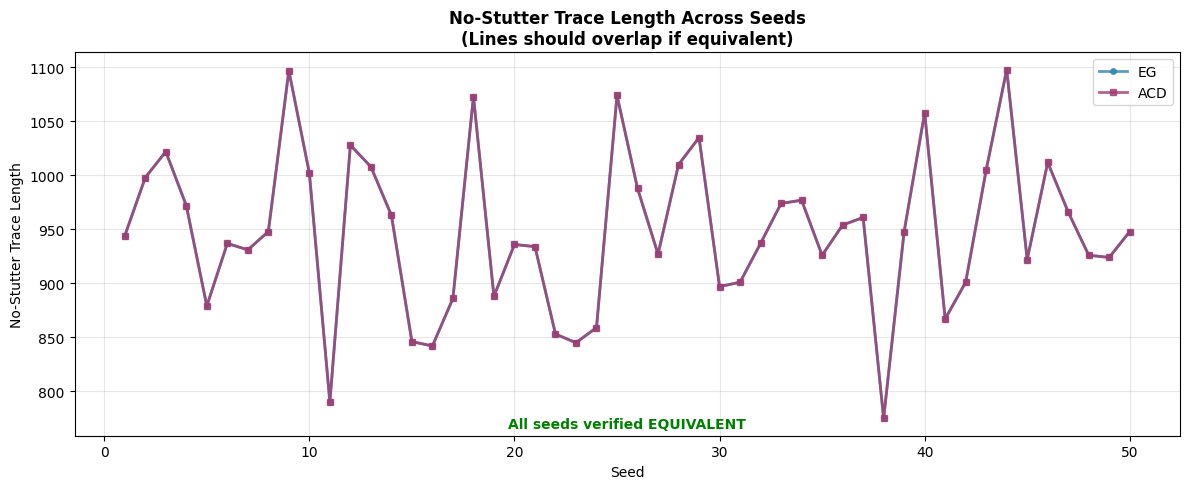

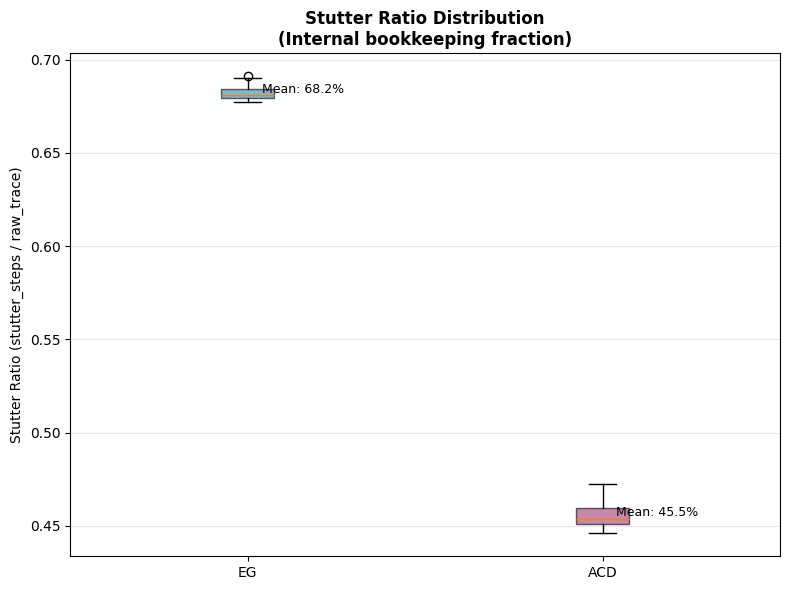

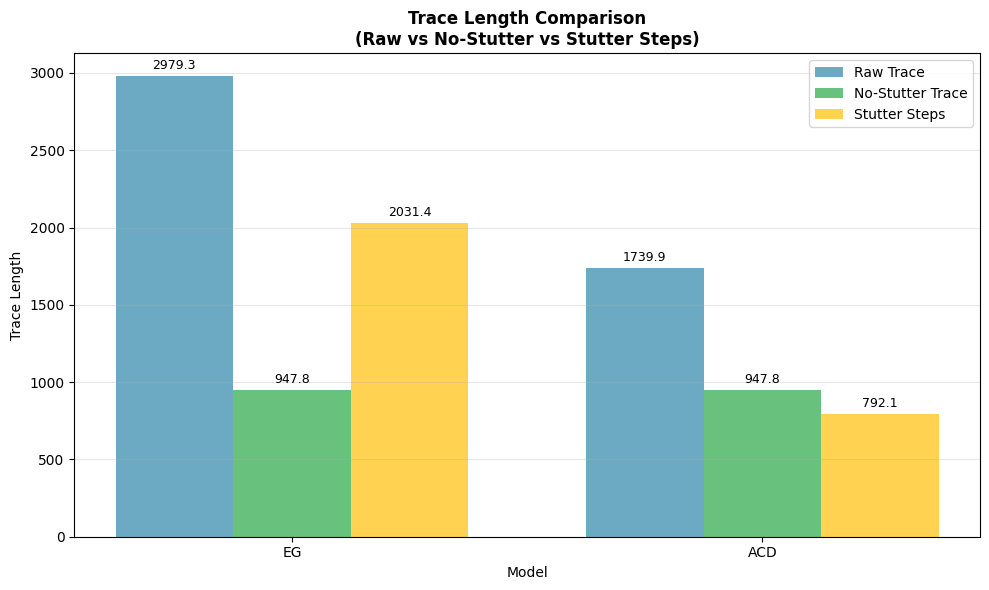

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


VERIFICATION SUMMARY

Status: EQUIVALENT
Time elapsed: 69.34s
Seeds verified: 50/50

Model Statistics:
--------------------------------------------------
  EG:
    Raw trace length:       2979.3
    No-stutter length:      947.8
    Stutter ratio:          68.2%
  ACD:
    Raw trace length:       1739.9
    No-stutter length:      947.8
    Stutter ratio:          45.5%

  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_htw8z3js\warehouse_multi_seed_verification.json


Model,Avg Raw Trace,Avg No-Stutter
EG,2979.3,947.8
ACD,1739.9,947.8


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'EG': {'avg_raw_length': 2979.26, 'avg_ns_length': 947.84, 'avg_stutter_steps': 2031.42, 'raw_length': 2979.26, 'ns_length': 947.84}, 'ACD': {'avg_raw_length': 1739.94, 'avg_ns_length': 947.84, 'avg_stutter_steps': 792.1, 'raw_length': 1739.94, 'ns_length': 947.84}}, first_difference_pos=None, time_elapsed=69.33805537223816, message='Models are W-STUTTER EQUIVALENT (verified over 50 seeds, 10000.0s each)', per_seed_stats=[PerSeedStats(seed=1, is_equivalent=True, model_stats={'EG': {'steps': 2928, 'final_time': 10000.866789369653, 'raw_length': 2929, 'ns_length': 944, 'stutter_steps': 1985}, 'ACD': {'steps': 1708, 'final_time': 10000.866789369653, 'raw_length': 1709, 'ns_length': 944, 'stutter_steps': 765}}), PerSeedStats(seed=2, is_equivalent=True, model_stats={'EG': {'steps': 3111, 'final_time': 10006.913998358417, 'raw_length': 3112, 'ns_length': 998, 'stutter_steps': 2114},

In [7]:
%%simasm verify
// Multi-seed verification using seed_range
// Full observation level: all 6 stations

verification Warehouse_Stutter_Equivalence_MultiSeed:
    models:
        import EG from "warehouse_eg"
        import ACD from "warehouse_acd"
    endmodels

    seed_range: 1 to 50

    labels:
        // Station S1 (Pick Zone A) - 4 servers
        label s1_busy_eq_0 for EG: "S1_capacity - S1 == 0"
        label s1_busy_eq_0 for ACD: "get_S1_busy() == 0"
        label s1_busy_eq_1 for EG: "S1_capacity - S1 == 1"
        label s1_busy_eq_1 for ACD: "get_S1_busy() == 1"
        label s1_busy_eq_2 for EG: "S1_capacity - S1 == 2"
        label s1_busy_eq_2 for ACD: "get_S1_busy() == 2"
        label s1_busy_eq_3 for EG: "S1_capacity - S1 == 3"
        label s1_busy_eq_3 for ACD: "get_S1_busy() == 3"
        label s1_busy_eq_4 for EG: "S1_capacity - S1 == 4"
        label s1_busy_eq_4 for ACD: "get_S1_busy() == 4"

        // Station S2 (Pick Zone B) - 2 servers
        label s2_busy_eq_0 for EG: "S2_capacity - S2 == 0"
        label s2_busy_eq_0 for ACD: "get_S2_busy() == 0"
        label s2_busy_eq_1 for EG: "S2_capacity - S2 == 1"
        label s2_busy_eq_1 for ACD: "get_S2_busy() == 1"
        label s2_busy_eq_2 for EG: "S2_capacity - S2 == 2"
        label s2_busy_eq_2 for ACD: "get_S2_busy() == 2"

        // Station S3 (Labelling) - 3 servers
        label s3_busy_eq_0 for EG: "S3_capacity - S3 == 0"
        label s3_busy_eq_0 for ACD: "get_S3_busy() == 0"
        label s3_busy_eq_1 for EG: "S3_capacity - S3 == 1"
        label s3_busy_eq_1 for ACD: "get_S3_busy() == 1"
        label s3_busy_eq_2 for EG: "S3_capacity - S3 == 2"
        label s3_busy_eq_2 for ACD: "get_S3_busy() == 2"
        label s3_busy_eq_3 for EG: "S3_capacity - S3 == 3"
        label s3_busy_eq_3 for ACD: "get_S3_busy() == 3"

        // Station S4 (Scanning) - 1 server
        label s4_busy_eq_0 for EG: "S4_capacity - S4 == 0"
        label s4_busy_eq_0 for ACD: "get_S4_busy() == 0"
        label s4_busy_eq_1 for EG: "S4_capacity - S4 == 1"
        label s4_busy_eq_1 for ACD: "get_S4_busy() == 1"

        // Station S5 (Packing) - 3 servers
        label s5_busy_eq_0 for EG: "S5_capacity - S5 == 0"
        label s5_busy_eq_0 for ACD: "get_S5_busy() == 0"
        label s5_busy_eq_1 for EG: "S5_capacity - S5 == 1"
        label s5_busy_eq_1 for ACD: "get_S5_busy() == 1"
        label s5_busy_eq_2 for EG: "S5_capacity - S5 == 2"
        label s5_busy_eq_2 for ACD: "get_S5_busy() == 2"
        label s5_busy_eq_3 for EG: "S5_capacity - S5 == 3"
        label s5_busy_eq_3 for ACD: "get_S5_busy() == 3"

        // Station S6 (Release) - 2 servers
        label s6_busy_eq_0 for EG: "S6_capacity - S6 == 0"
        label s6_busy_eq_0 for ACD: "get_S6_busy() == 0"
        label s6_busy_eq_1 for EG: "S6_capacity - S6 == 1"
        label s6_busy_eq_1 for ACD: "get_S6_busy() == 1"
        label s6_busy_eq_2 for EG: "S6_capacity - S6 == 2"
        label s6_busy_eq_2 for ACD: "get_S6_busy() == 2"
    endlabels

    observables:
        // S1 observables
        observable s1_busy_eq_0: EG -> s1_busy_eq_0  ACD -> s1_busy_eq_0 endobservable
        observable s1_busy_eq_1: EG -> s1_busy_eq_1  ACD -> s1_busy_eq_1 endobservable
        observable s1_busy_eq_2: EG -> s1_busy_eq_2  ACD -> s1_busy_eq_2 endobservable
        observable s1_busy_eq_3: EG -> s1_busy_eq_3  ACD -> s1_busy_eq_3 endobservable
        observable s1_busy_eq_4: EG -> s1_busy_eq_4  ACD -> s1_busy_eq_4 endobservable

        // S2 observables
        observable s2_busy_eq_0: EG -> s2_busy_eq_0  ACD -> s2_busy_eq_0 endobservable
        observable s2_busy_eq_1: EG -> s2_busy_eq_1  ACD -> s2_busy_eq_1 endobservable
        observable s2_busy_eq_2: EG -> s2_busy_eq_2  ACD -> s2_busy_eq_2 endobservable

        // S3 observables
        observable s3_busy_eq_0: EG -> s3_busy_eq_0  ACD -> s3_busy_eq_0 endobservable
        observable s3_busy_eq_1: EG -> s3_busy_eq_1  ACD -> s3_busy_eq_1 endobservable
        observable s3_busy_eq_2: EG -> s3_busy_eq_2  ACD -> s3_busy_eq_2 endobservable
        observable s3_busy_eq_3: EG -> s3_busy_eq_3  ACD -> s3_busy_eq_3 endobservable

        // S4 observables
        observable s4_busy_eq_0: EG -> s4_busy_eq_0  ACD -> s4_busy_eq_0 endobservable
        observable s4_busy_eq_1: EG -> s4_busy_eq_1  ACD -> s4_busy_eq_1 endobservable

        // S5 observables
        observable s5_busy_eq_0: EG -> s5_busy_eq_0  ACD -> s5_busy_eq_0 endobservable
        observable s5_busy_eq_1: EG -> s5_busy_eq_1  ACD -> s5_busy_eq_1 endobservable
        observable s5_busy_eq_2: EG -> s5_busy_eq_2  ACD -> s5_busy_eq_2 endobservable
        observable s5_busy_eq_3: EG -> s5_busy_eq_3  ACD -> s5_busy_eq_3 endobservable

        // S6 observables
        observable s6_busy_eq_0: EG -> s6_busy_eq_0  ACD -> s6_busy_eq_0 endobservable
        observable s6_busy_eq_1: EG -> s6_busy_eq_1  ACD -> s6_busy_eq_1 endobservable
        observable s6_busy_eq_2: EG -> s6_busy_eq_2  ACD -> s6_busy_eq_2 endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 10000.0
        timeout: 120
    endcheck

    output:
        format: "json"
        file_path: "warehouse_multi_seed_verification.json"
        include_counterexample: true
        generate_plots: true
    endoutput
endverification

## Summary

This notebook demonstrated:

1. **Complex Multi-Station Model**: A 6-station warehouse outbound process with 4 input streams and varying server capacities

2. **Dual Formalism Generation**: Generated both Event Graph (36 vertices) and ACD (10 activities) models from JSON specifications

3. **Comprehensive Observation Level**: Verified equivalence using 20 atomic propositions (busy server counts for all 6 stations)

4. **Multi-Seed Verification**: Confirmed W-stutter equivalence across 50 random seeds

5. **Automatic Visualization**: Enabled `generate_plots: true` to produce:
   - **Trace Comparison**: Bar chart showing raw vs no-stutter trace lengths
   - **NS Convergence**: Line plot of no-stutter lengths across seeds (overlapping lines confirm equivalence)
   - **Stutter Distribution**: Box plot of stutter ratio distribution per model

### Key Findings

- Both formalisms produce identical no-stutter traces (mean: 948 steps)
- The EG model averaged 2,979 raw steps vs ACD's 1,740 raw steps (71% more)
- This difference reflects EG's explicit decision vertices vs ACD's implicit activity logic
- Behavioral equivalence holds despite structural differences
- Stutter abstraction removes formalism-specific internal bookkeeping